 ### The goal of this notebook is to create the VRAD vs Phi1 plot for the PAI paper

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy import table
import pandas as pd


In [2]:
DATA_PATH = '/pscratch/sd/p/pratsosa/DESI_data'


In [3]:
gd1_desi_mems = Table.read(f'{DATA_PATH}/GD1_DESI_memprob.fits')


In [4]:
gd1_desi_mems.colnames


['VRAD',
 'VRAD_ERR',
 'VRAD_SKEW',
 'VRAD_KURT',
 'VSINI',
 'LOGG',
 'LOGG_ERR',
 'TEFF',
 'TEFF_ERR',
 'FEH',
 'FEH_ERR',
 'ALPHAFE',
 'ALPHAFE_ERR',
 'CHISQ_TOT',
 'CHISQ_C_TOT',
 'NPIX_TOT',
 'CHISQ_B',
 'CHISQ_C_B',
 'CHISQ_R',
 'CHISQ_C_R',
 'CHISQ_Z',
 'CHISQ_C_Z',
 'VRAD_CCF',
 'RVS_WARN',
 'REF_ID',
 'REF_CAT',
 'TARGET_RA',
 'TARGET_DEC',
 'TARGETID',
 'SN_B',
 'SN_R',
 'SN_Z',
 'SUCCESS',
 'RR_Z',
 'RR_SPECTYPE',
 'HEALPIX',
 'SURVEY',
 'PROGRAM',
 'PRIMARY',
 'SOURCE_ID',
 'RANDOM_INDEX',
 'REF_EPOCH',
 'RA',
 'RA_ERROR',
 'DEC',
 'DEC_ERROR',
 'PARALLAX',
 'PARALLAX_ERROR',
 'PARALLAX_OVER_ERROR',
 'PMRA',
 'PMRA_ERROR',
 'PMDEC',
 'PMDEC_ERROR',
 'RA_DEC_CORR',
 'RA_PARALLAX_CORR',
 'RA_PMRA_CORR',
 'RA_PMDEC_CORR',
 'DEC_PARALLAX_CORR',
 'DEC_PMRA_CORR',
 'DEC_PMDEC_CORR',
 'PARALLAX_PMRA_CORR',
 'PARALLAX_PMDEC_CORR',
 'PMRA_PMDEC_CORR',
 'ASTROMETRIC_N_OBS_AL',
 'ASTROMETRIC_N_OBS_AC',
 'ASTROMETRIC_N_GOOD_OBS_AL',
 'ASTROMETRIC_N_BAD_OBS_AL',
 'ASTROMETRIC_GOF_AL',
 '

In [5]:
# cols_to_keep_gd1 = ['SOURCE_ID', 'RA', 'DEC', 'VRAD', 'VRAD_ERR', 'p_stream', 'p_cocoon']
cols_to_keep_gd1 = ['SOURCE_ID', 'p_stream', 'p_cocoon']
gd1_desi_mems = gd1_desi_mems[cols_to_keep_gd1]


In [6]:
np.sum(np.array(gd1_desi_mems['p_stream']) > 0.5)


np.int64(419)

In [7]:
# Load the DESI catalog from two extensions, mirroring the pattern used for
# rvpix-loa.fits. RVTAB holds the spectroscopic measurements (VRAD, VRAD_ERR)
# and GAIA holds the Gaia cross-match including SOURCE_ID.
DR1_DESI_rvtab = Table.read(f'{DATA_PATH}/mwsall-pix-iron.fits', hdu='RVTAB', mask_invalid=False)
DR1_DESI_gaia  = Table.read(f'{DATA_PATH}/mwsall-pix-iron.fits', hdu='GAIA',  mask_invalid=False)

# Attach the Gaia SOURCE_ID to the spectroscopic table. The two extensions are
# row-aligned (same length, same order), so direct column assignment is safe.
DR1_DESI_rvtab['source_id'] = DR1_DESI_gaia['SOURCE_ID'].astype(np.int64)


In [8]:
# Keep only the columns we need from the DESI catalog.
cols_to_keep_desi = ['source_id', 'VRAD', 'VRAD_ERR']
DR1_DESI_cat = DR1_DESI_rvtab[cols_to_keep_desi]


In [9]:
# FIX 1: Drop invalid source_id rows, then deduplicate the DESI catalog.
# The GAIA extension uses a masked column for SOURCE_ID: some rows are masked
# entirely (not just zero), and astropy.table.join refuses to join on a key
# column that contains masked values. We therefore drop both masked rows and
# the known sentinel value of 0 before proceeding.
desi_df = DR1_DESI_cat.to_pandas()
# source_id is int64; masked entries become NaN when converted to pandas.
# Drop rows where source_id is NaN (was masked) or 0 (invalid sentinel).
desi_df = desi_df.dropna(subset=['source_id'])
desi_df = desi_df[desi_df['source_id'] != 0]
desi_df['source_id'] = desi_df['source_id'].astype(np.int64)
# Keep the single best-quality (lowest VRAD_ERR) observation per source.
desi_df = desi_df.sort_values('VRAD_ERR', ascending=True)
desi_df = desi_df.drop_duplicates(subset=['source_id'], keep='first')
DR1_DESI_cat = Table.from_pandas(desi_df)
print(f'{len(DR1_DESI_cat)} unique Gaia sources with valid DESI VRAD measurements')


4906665 unique Gaia sources with valid DESI VRAD measurements


In [10]:
# Now load in my data for GD-1, has RA and Dec which we'll use to cross-match
# with the DESI data and get the VRAD values for the GD-1 members.

GD1_gaia_decals = Table.read('/pscratch/sd/p/pratsosa/GD-1_gaia_x_decals_040726.fits')
preds = pd.read_csv('/pscratch/sd/p/pratsosa/GD1_SCREAM/results/cv_test_cv_predictions.csv')


In [11]:
# FIX 2: Coerce source_id to int64 before converting to an Astropy Table.
# pandas reads CSV source_id columns as float64 by default (due to potential NaNs),
# but the FITS file stores them as int64. A type mismatch causes the join to fail
# or produce zero matches.
preds['source_id'] = preds['source_id'].astype(np.int64)
preds = Table.from_pandas(preds)


In [12]:
# Cross match my own data (GD1_gaia_decals and preds) to each other using the source_id column
GD1_gaia_decals = table.join(GD1_gaia_decals, preds, keys='source_id')


In [13]:
# FIX 3 (supersedes coordinate crossmatch): Join GD1_gaia_decals to the DESI
# catalog on source_id. This is exact and unambiguous — no sky separation
# threshold is needed. A left join preserves all of our stars and gives NaN
# (masked) VRAD/VRAD_ERR for stars with no DESI observation.
GD1_gaia_decals = table.join(
    GD1_gaia_decals,
    DR1_DESI_cat,
    keys='source_id',
    join_type='left',
)

# Rename the joined VRAD columns for clarity.
GD1_gaia_decals.rename_column('VRAD', 'DESI_VRAD')
GD1_gaia_decals.rename_column('VRAD_ERR', 'DESI_VRAD_ERR')

# Convert masked columns to plain float arrays with NaN for unmatched rows.
desi_vrad     = np.where(np.ma.getmaskarray(GD1_gaia_decals['DESI_VRAD']),
                         np.nan,
                         np.ma.getdata(GD1_gaia_decals['DESI_VRAD']).astype(float))
desi_vrad_err = np.where(np.ma.getmaskarray(GD1_gaia_decals['DESI_VRAD_ERR']),
                         np.nan,
                         np.ma.getdata(GD1_gaia_decals['DESI_VRAD_ERR']).astype(float))
GD1_gaia_decals['DESI_VRAD']     = desi_vrad
GD1_gaia_decals['DESI_VRAD_ERR'] = desi_vrad_err

n_matched = np.isfinite(desi_vrad).sum()
print(f'{n_matched} / {len(GD1_gaia_decals)} stars have a DESI VRAD measurement')


5191 / 37567 stars have a DESI VRAD measurement


In [14]:
model_probs = GD1_gaia_decals['model_prob']
pred_mask = model_probs > 0.91
vrad = np.array(GD1_gaia_decals['DESI_VRAD'])
vrad_err = np.array(GD1_gaia_decals['DESI_VRAD_ERR'])
phi1 = np.array(GD1_gaia_decals['phi1'])


In [18]:
# plot VRAD vs phi1 for the GD-1 members
# Only plot stars that (a) pass the model probability cut and (b) have a real
# DESI match (i.e. DESI_VRAD is not NaN).
has_vrad = np.isfinite(vrad)
plot_mask = pred_mask & has_vrad
print(f'Plotting {plot_mask.sum()} stars with model_prob > 0.91 and valid DESI VRAD')


Plotting 170 stars with model_prob > 0.91 and valid DESI VRAD


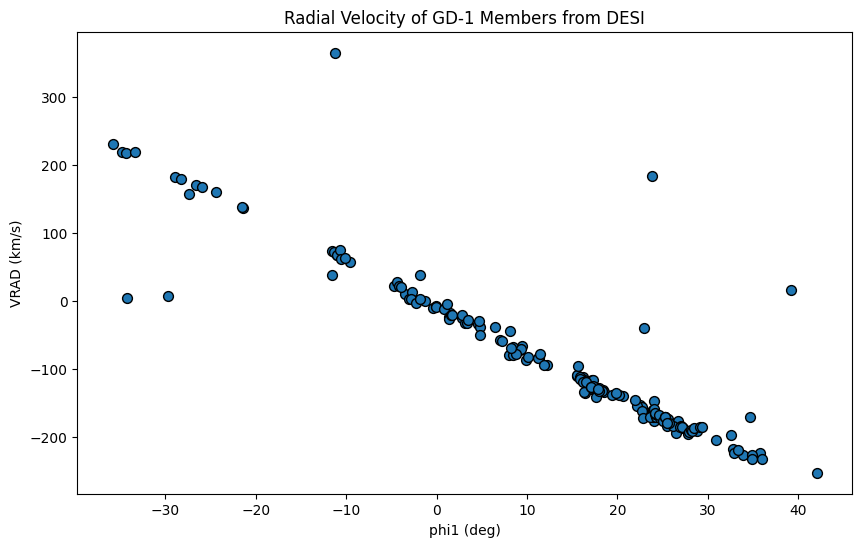

In [19]:

fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(phi1[plot_mask], vrad[plot_mask], c='C0', s=50, edgecolor='k')
ax.set_xlabel('phi1 (deg)')
ax.set_ylabel('VRAD (km/s)')
ax.set_title('Radial Velocity of GD-1 Members from DESI')
# ax.set_ylim(-400, 400)
plt.show()


In [20]:
# Now crossmatch to gd1_desi_mems using the source_id column.
# gd1_desi_mems calls it SOURCE_ID, while GD1_gaia_decals calls it source_id,
# so rename the column in gd1_desi_mems to source_id.
# We do a left join so that rows in GD1_gaia_decals with no match in gd1_desi_mems
# receive masked (NaN-equivalent) values for p_stream and p_cocoon rather than
# being dropped entirely.
gd1_desi_mems.rename_column('SOURCE_ID', 'source_id')
GD1_gaia_decals = table.join(GD1_gaia_decals, gd1_desi_mems, keys='source_id', join_type='left')


In [ ]:
# FIX 4: Extract the masked-array mask BEFORE casting to numeric types.
# After a left join Astropy uses masked columns for unmatched rows. Casting a
# masked column directly to int/float fills masked positions with the column's
# fill_value (often 0 or a sentinel), which silently labels unmatched stars as
# background. We capture the mask first so we can exclude those rows from
# any downstream metric that requires a known DESI label.
p_stream_arr = np.ma.getdata(GD1_gaia_decals['p_stream']).astype(float)
p_cocoon_arr = np.ma.getdata(GD1_gaia_decals['p_cocoon']).astype(float)

# True where the star has NO entry in the collaborator's DESI membership table.
no_desi_label_mask = np.ma.getmaskarray(GD1_gaia_decals['p_stream'])

# Set p values to NaN for unmatched rows so comparisons behave correctly.
p_stream_arr[no_desi_label_mask] = np.nan
p_cocoon_arr[no_desi_label_mask] = np.nan


In [ ]:
np.sum(np.array(GD1_gaia_decals['p_stream'] > 0.5))


In [ ]:
# Create a new column in GD1_gaia_decals called desi_label:
#   1  if p_stream > 0.5 OR p_cocoon > 0.5  (stream / cocoon member)
#   0  if both are <= 0.5                    (confirmed background)
#  -1  if the star has no entry in the collaborator table (unknown / not observed)
p_cocoon_mask = p_cocoon_arr > 0.5
p_stream_mask = p_stream_arr > 0.5

desi_label = np.where(
    no_desi_label_mask,
    -1,                                           # no collaborator label
    np.where(p_cocoon_mask | p_stream_mask, 1, 0) # member vs background
)
GD1_gaia_decals['desi_label'] = desi_label


In [ ]:
np.sum(np.array(GD1_gaia_decals['p_stream'] > 0.5))


In [ ]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

_RC = {
    "font.size": 14,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "axes.linewidth": 1.0,
}

_CLASS_LABELS = ["Background", "Stream"]


def plot_confusion_matrix(
    true_labels: np.ndarray,
    preds: np.ndarray,
    output_path: Path,
) -> None:
    """Write two confusion-matrix PNGs for DESI labels vs model predictions.

    Parameters
    ----------
    true_labels : array of int/bool, shape (N,)
        DESI-derived labels in ``desi_label``.
    preds : array of int/bool, shape (N,)
        Thresholded model predictions from ``model_prob > 0.91``.
    output_path : Path without extension.
        Writes:
            {output_path}_norm.png  - pred-normalized
            {output_path}_raw.png   - raw counts
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    cm_raw = confusion_matrix(true_labels, preds, normalize=None)
    cm_norm = confusion_matrix(true_labels, preds, normalize="pred")

    with matplotlib.rc_context(_RC):
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".2%",
            cmap="Blues",
            cbar=True,
            annot_kws={"fontsize": 30},
            cbar_kws={"label": "Fraction of predicted class"},
            square=True,
            linewidths=0.5,
            linecolor="white",
            xticklabels=_CLASS_LABELS,
            yticklabels=_CLASS_LABELS,
            vmin=0,
            vmax=1,
            ax=ax,
        )
        ax.tick_params(axis="both", labelsize=22)
        ax.set_xlabel("Predicted label", fontsize=26)
        ax.set_ylabel("DESI label", fontsize=26)
        fig.savefig(str(output_path) + "_norm.png", dpi=600, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(
            cm_raw,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=True,
            annot_kws={"fontsize": 30},
            square=True,
            linewidths=0.5,
            linecolor="white",
            xticklabels=_CLASS_LABELS,
            yticklabels=_CLASS_LABELS,
            ax=ax,
        )
        ax.tick_params(axis="both", labelsize=22)
        ax.set_xlabel("Predicted label", fontsize=26)
        ax.set_ylabel("DESI label", fontsize=26)
        plt.show()
        # fig.savefig(str(output_path) + "_raw.png", dpi=600, bbox_inches="tight", pad_inches=0)
        # plt.close(fig)



In [ ]:
# FIX 5: Build valid_mask from the desi_label sentinel value and from
# model_prob, NOT from np.isfinite on an integer array.
# desi_label == -1 means the star has no collaborator label and must be excluded.
# We also exclude any star whose model_prob is non-finite.
pred_probs = np.asarray(GD1_gaia_decals["model_prob"], dtype=float)
true_labels = np.asarray(GD1_gaia_decals["desi_label"], dtype=int)
model_preds = (pred_probs > 0.91).astype(int)

# Only include stars that have a known DESI label (0 or 1) and a finite model prob.
valid_mask = (true_labels >= 0) & np.isfinite(pred_probs)
print(f'{valid_mask.sum()} stars with known DESI labels available for confusion matrix')

plot_confusion_matrix(
    true_labels[valid_mask],
    model_preds[valid_mask],
    Path("/pscratch/sd/p/pratsosa/GD1_SCREAM/results/desi_label_vs_model_prob_091_confusion_matrix"),
)



 ## Missing stars check

In [ ]:
# Check if any of the stars in gd1_desi_mems were not in the GD1_gaia_decals table, if so print out their source_id values.
mask = np.isin(gd1_desi_mems['source_id'], GD1_gaia_decals['source_id'])
missing_source_ids = gd1_desi_mems['source_id'][~mask]
print(len(missing_source_ids))


In [ ]:
# Check to see if these missing source_ids are in the hdf5 table given by '/pscratch/sd/p/pratsosa/fetcher_output_new/GD-1-I21/GD-1-I21_matched.hdf5'

import h5py
hdf5_path = '/pscratch/sd/p/pratsosa/fetcher_output_new/GD-1-I21/GD-1-I21_matched.hdf5'
hdf5_table = Table.read(hdf5_path, path='data')
hdf5_source_ids = hdf5_table['source_id']
missing_in_hdf5 = np.isin(missing_source_ids, hdf5_source_ids)
print(np.sum(missing_in_hdf5))


In [ ]:
# Length of gd1_desi_mems
print(len(gd1_desi_mems))
